In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

In [38]:
!pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast?select=train.csv')

Skipping, found downloaded files in "./walmart-sales-forecast" (use force=True to force download)


# ----------------------------
# 2. Load Data
# ----------------------------

In [39]:
features_df = pd.read_csv('/content/walmart-sales-forecast/features.csv')
stores_df   = pd.read_csv('/content/walmart-sales-forecast/stores.csv')
test_df     = pd.read_csv('/content/walmart-sales-forecast/test.csv')
train_df    = pd.read_csv('/content/walmart-sales-forecast/train.csv')

In [40]:
# features_df.head()
# stores_df.head()
# test_df.head()
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# ----------------------------
# 4. Fix IsHoliday Column Conflicts
# ----------------------------
# Rename IsHoliday_x → IsHoliday, drop IsHoliday_y

In [41]:
for df in [train_merged, test_merged]:
    if 'IsHoliday_x' in df.columns:
        df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
    if 'IsHoliday_y' in df.columns:
        df.drop(columns=['IsHoliday_y'], inplace=True)

# ----------------------------
# 3. Merge Data
# ----------------------------

In [42]:
# Merge train with features and stores
train_merged = pd.merge(train_df, features_df, on=["Store", "Date"], how="left")
train_merged = pd.merge(train_merged, stores_df, on="Store", how="left")

# Merge test with features and stores
test_merged = pd.merge(test_df, features_df, on=["Store", "Date"], how="left")
test_merged = pd.merge(test_merged, stores_df, on="Store", how="left")


# ---- FIX HOLIDAY COLUMNS HERE ----
for df in [train_merged, test_merged]:
    if 'IsHoliday_x' in df.columns:
        df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
    if 'IsHoliday_y' in df.columns:
        df.drop(columns=['IsHoliday_y'], inplace=True)

print("Train shape:", train_merged.shape)
print("Test shape:", test_merged.shape)
print("Columns:", train_merged.columns.tolist())  # <-- confirm IsHoliday exists

Train shape: (421570, 16)
Test shape: (115064, 15)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


# ----------------------------
# 4. Feature Engineering
# ----------------------------

In [43]:
train_merged['Date'] = pd.to_datetime(train_merged['Date'])
test_merged['Date']  = pd.to_datetime(test_merged['Date'])

# Sort

In [44]:
train_merged = train_merged.sort_values(["Store", "Dept", "Date"])

# Date features

In [45]:
for df in [train_merged, test_merged]:
    df['Year']  = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

# Lag features (1 and 2 weeks back)

In [46]:
train_merged['Weekly_Sales_Lag1'] = train_merged.groupby(["Store", "Dept"])['Weekly_Sales'].shift(1)
train_merged['Weekly_Sales_Lag2'] = train_merged.groupby(["Store", "Dept"])['Weekly_Sales'].shift(2)

train_merged = train_merged.dropna()

# ----------------------------
# 5. Train/Validation Split
# ----------------------------

In [47]:
train_set = train_merged[train_merged['Year'] < 2012]
valid_set = train_merged[train_merged['Year'] == 2012]

features = ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
            'CPI', 'Unemployment', 'Type', 'Size',
            'Year', 'Month', 'Week', 'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2']

X_train = train_set[features]
y_train = train_set['Weekly_Sales']
X_valid = valid_set[features]
y_valid = valid_set['Weekly_Sales']

# ----------------------------
# 7. Encode Categorical Vars
# ----------------------------

In [50]:
le = LabelEncoder()
for col in ['Type']:
    X_train[col] = le.fit_transform(X_train[col])
    X_valid[col] = le.transform(X_valid[col])

/tmp/ipython-input-3831331708.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = le.fit_transform(X_train[col])
/tmp/ipython-input-3831331708.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid[col] = le.transform(X_valid[col])


# ----------------------------
# 8. Train Model
# ----------------------------

In [53]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_valid, y_valid)],
          verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# ----------------------------
# 9. Evaluation
# ----------------------------

In [54]:
y_pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 9336.70


# ----------------------------
# 10. Plot Actual vs Predicted
# ----------------------------

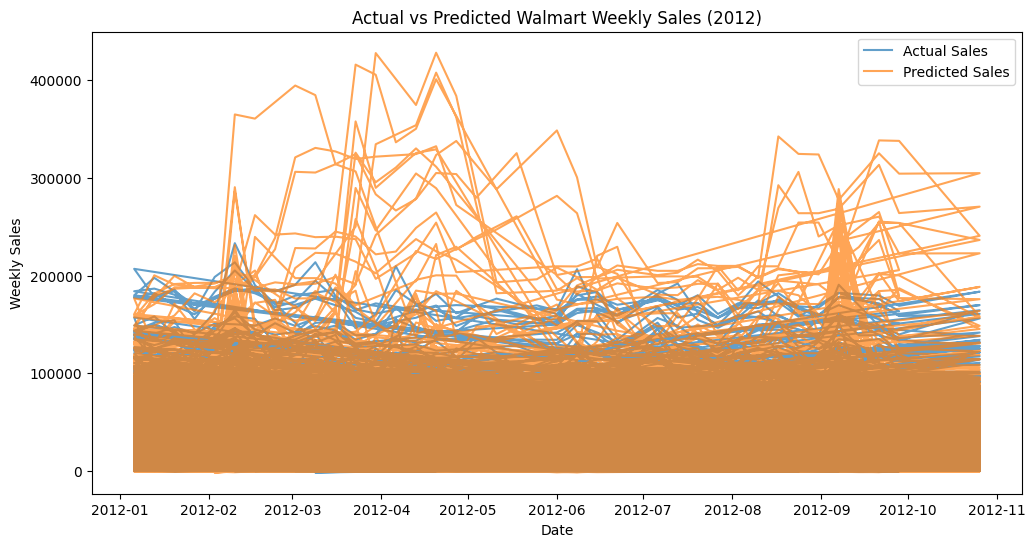

In [55]:
plt.figure(figsize=(12,6))
plt.plot(valid_set['Date'], y_valid, label="Actual Sales", alpha=0.7)
plt.plot(valid_set['Date'], y_pred, label="Predicted Sales", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Actual vs Predicted Walmart Weekly Sales (2012)")
plt.legend()
plt.show()